In [1]:
!git clone https://github.com/quark28/miniml.git
%cd miniml

Cloning into 'miniml'...
remote: Enumerating objects: 358, done.
remote: Counting objects: 100% (154/154), done.
remote: Compressing objects: 100% (105/105), done.
remote: Total 358 (delta 100), reused 98 (delta 49), pack-reused 204 (from 1)
Receiving objects: 100% (358/358), 2.47 MiB | 13.95 MiB/s, done.
Resolving deltas: 100% (195/195), done.
/content/miniml


In [2]:
from miniml.tree_based.gradientboostingbinaryclassifier import GradientBoostingBinaryClassification

In [4]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, log_loss

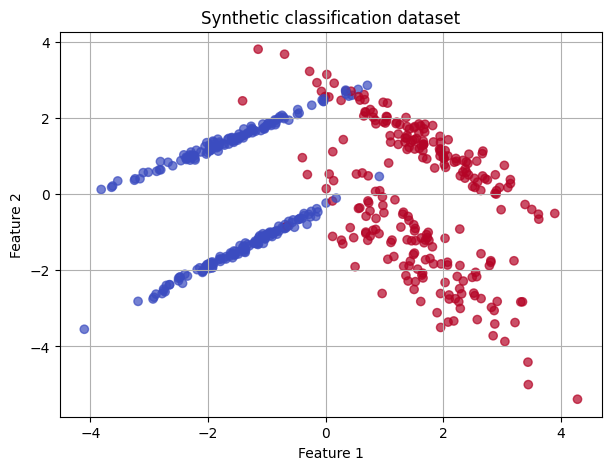

In [5]:
X, y = make_classification(
    n_samples=500,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    n_clusters_per_class=2,
    class_sep=1.5,
    random_state=42
)

plt.figure(figsize=(7,5))

plt.scatter(
    X[:,0],
    X[:,1],
    c=y,
    cmap="coolwarm",
    alpha=0.7
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Synthetic classification dataset")
plt.grid()

plt.show()

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42
)

In [8]:
gb = GradientBoostingBinaryClassification(
    n_estimators=50,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb.fit(
    X_train,
    y_train
)

In [9]:
pred = gb.predict(X_test)

acc = accuracy_score(
    y_test,
    pred
)

print("Accuracy:", acc)

Accuracy: 0.952


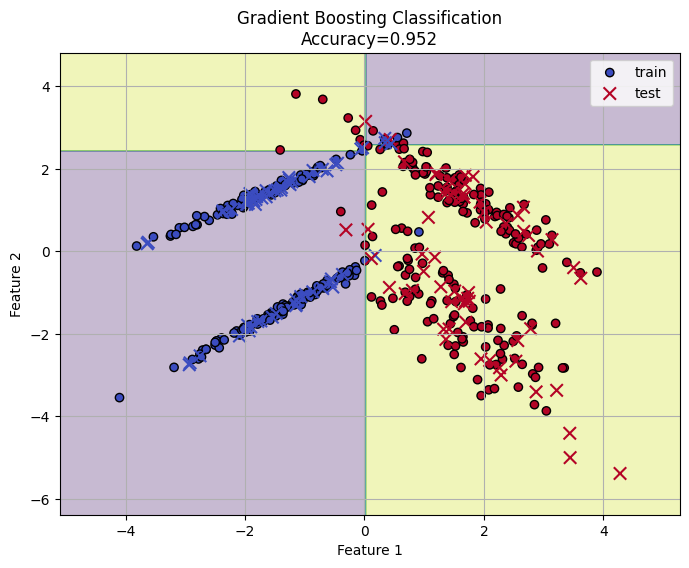

In [10]:
xx, yy = np.meshgrid(
    np.linspace(
        X[:,0].min()-1,
        X[:,0].max()+1,
        300
    ),
    np.linspace(
        X[:,1].min()-1,
        X[:,1].max()+1,
        300
    )
)

grid = np.c_[xx.ravel(), yy.ravel()]

z = gb.predict(grid)

z = z.reshape(xx.shape)


plt.figure(figsize=(8,6))


plt.contourf(
    xx,
    yy,
    z,
    alpha=0.3
)


plt.scatter(
    X_train[:,0],
    X_train[:,1],
    c=y_train,
    cmap="coolwarm",
    edgecolors="k",
    label="train"
)


plt.scatter(
    X_test[:,0],
    X_test[:,1],
    c=y_test,
    cmap="coolwarm",
    marker="x",
    s=80,
    label="test"
)


plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title(
    f"Gradient Boosting Classification\nAccuracy={acc:.3f}"
)

plt.legend()
plt.grid()

plt.show()

In [11]:
print("Trees:", len(gb.ensemble))
print("Initial logit:", gb.init_prediction)

print(
    "Train accuracy:",
    accuracy_score(
        y_train,
        gb.predict(X_train)
    )
)

print(
    "Test accuracy:",
    accuracy_score(
        y_test,
        gb.predict(X_test)
    )
)

Trees: 50
Initial logit: 0.005333345975362382
Train accuracy: 0.984
Test accuracy: 0.952
